<a href="https://colab.research.google.com/github/yuanzhouwang/ConformalHMM/blob/main/latent_regime_conformal_main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GSC + latent-regime conformal simulation

Simulates Algorithm 1 vs. Chernozhukov et al

In [ ]:
# Colab setup
# Minimal setup for GPU-batched simulation.
!pip -q install rpy2 pyarrow
!apt-get -qq update
!apt-get -qq install -y r-base r-base-dev libcurl4-openssl-dev libssl-dev libxml2-dev
!R -q -e 'install.packages(c("gsynth","data.table","dplyr"), repos="https://cloud.r-project.org")'
%load_ext rpy2.ipython


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
W: Failed to fetch http://archive.ubuntu.com/ubuntu/dists/jammy/InRelease  Connection failed [IP: 91.189.91.83 80]
W: Failed to fetch http://archive.ubuntu.com/ubuntu/dists/jammy-updates/InRelease  Connection failed [IP: 91.189.91.83 80]
W: Failed to fetch http://archive.ubuntu.com/ubuntu/dists/jammy-backports/InRelease  Connection failed [IP: 91.189.92.22 80]
W: Failed to fetch https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu/dists/jammy/InRelease  Could not connect to ppa.launchpadcontent.net:443 (185.125.190.80), connection timed out
W: Failed to fetch https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu/dists/jammy/InRelease  Unable to connect to ppa.launchpadcontent.net:443:
W: Failed to fetch https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu/dists/jammy/InRelease  Unable to co

In [ ]:
%%R
library(gsynth)
fit_gsc_once <- function(df, seed = 538) {
  out <- gsynth(
    Y ~ D + X1 + X2 + X3 + X4,
    data = as.data.frame(df),
    index = c('unit', 'time'),
    force = 'two-way',
    r = 0:3,
    CV = TRUE,
    se = FALSE,
    inference = 'none',
    parallel = FALSE,
    seed = seed
  )
  list(Y_ct = out$Y.ct, Y_tr = out$Y.tr, r_cv = out$r.cv, sigma2 = out$sigma2)
}

## v1.4.0: estimator='ife' now uses the EM algorithm; default is 'gsynth'. See ?gsynth.
## Since v.1.3.0, *gsynth* is a wrapper of the *fect* package.


In [ ]:
import os, json, warnings, math, numpy as np, pandas as pd, matplotlib.pyplot as plt, torch
from dataclasses import dataclass
from sklearn.preprocessing import KBinsDiscretizer
from tqdm.auto import tqdm
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri

warnings.filterwarnings("ignore")
pandas2ri.activate()
fit_gsc_once_r = ro.globalenv["fit_gsc_once"]

SEED = 20260416
ALPHA = 0.10   # miscoverage; target coverage is 0.90
N_REP = 10
N_DONORS = 20
T_TOTAL = 36
T0 = 24
T1 = T_TOTAL - T0
N_CANDIDATES = 500
N_PERM = 400
N_BINS = 3

# GPU batching controls
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float32
CAND_BATCH_SIZE = 128
TORCH_SEED = SEED
torch.manual_seed(TORCH_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(TORCH_SEED)
print({"DEVICE": DEVICE, "CAND_BATCH_SIZE": CAND_BATCH_SIZE})

@dataclass
class SimulatedPanel:
    panel_df: pd.DataFrame
    true_regime: np.ndarray
    true_y0_untreated: np.ndarray
    observed_y0: np.ndarray

def simulate_markov_regime(T, rng, t0, P_pre_treatment, P_post_treatment=None):
    z = np.zeros(T, dtype=int)
    z[0] = rng.integers(0,3)
    current_P = P_pre_treatment
    for t in range(1, T):
        if P_post_treatment is not None and t >= t0:
            current_P = P_post_treatment
        z[t] = rng.choice(np.arange(3), p=current_P[z[t-1]])
    return z

def simulate_panel_once(seed):
    rng = np.random.default_rng(seed)
    units = np.arange(N_DONORS + 1)

    P_pre_treatment = np.array([[0.85,0.10,0.05],[0.10,0.80,0.10],[0.05,0.15,0.80]])
    P_post_treatment = np.array([[0.70,0.20,0.10],[0.20,0.60,0.20],[0.10,0.20,0.70]]) # More volatile P matrix

    z_treated = simulate_markov_regime(T_TOTAL, rng, T0, P_pre_treatment, P_post_treatment)
    regime_sigma = np.array([2.0, 5.5, 8.5])
    f = np.zeros((T_TOTAL, 2))
    for t in range(1, T_TOTAL):
        f[t,0] = 0.70*f[t-1,0] + rng.normal(0,0.6)
        f[t,1] = 0.55*f[t-1,1] + rng.normal(0,0.5)
    lambdas = rng.normal(0,0.7,size=(len(units),2))
    betas = np.array([0.8,-0.5,0.4,0.3])
    rows=[]; y_prev=np.zeros(len(units)); X_prev=rng.normal(size=(len(units),4))
    true_y0=np.zeros(T_TOTAL); y_obs0=np.zeros(T_TOTAL)
    tau=np.zeros(T_TOTAL); tau[T0:] = 1.2 + 0.15*np.arange(T1) + 0.6*np.sin(np.arange(T1)/2)
    for t in range(T_TOTAL):
        X_now=np.zeros_like(X_prev)
        X_now[:,0]=0.55*X_prev[:,0] + 0.25*f[t,0] + rng.normal(0,0.7,len(units))
        X_now[:,1]=0.45*X_prev[:,1] - 0.20*f[t,1] + rng.normal(0,0.6,len(units))
        X_now[:,2]=0.60*X_prev[:,2] + rng.normal(0,0.8,len(units))
        X_now[:,3]=0.35*X_prev[:,3] + 0.15*f[t,0] + 0.10*f[t,1] + rng.normal(0,0.8,len(units))
        for i, unit in enumerate(units):
            donor_sigma = 0.45 + 0.10*((unit % 3)/2.0)
            eps_sd = regime_sigma[z_treated[t]] if unit == 0 else donor_sigma
            y0 = 0.45*y_prev[i] + X_now[i]@betas + lambdas[i]@f[t] + rng.normal(0, eps_sd)
            D = int((unit == 0) and (t >= T0))
            y = y0 + (tau[t] if D else 0.0)
            rows.append({'unit':int(unit),'time':int(t+1),'Y':float(y),'D':D,'X1':float(X_now[i,0]),'X2':float(X_now[i,1]),'X3':float(X_now[i,2]),'X4':float(X_now[i,3])})
            if unit == 0:
                true_y0[t]=y0; y_obs0[t]=y
            y_prev[i]=y0
        X_prev=X_now
    return SimulatedPanel(pd.DataFrame(rows), z_treated, true_y0, y_obs0)

def fit_gsc_first_stage(panel_df):
    res = fit_gsc_once_r(pandas2ri.py2rpy(panel_df[['unit','time','Y','D','X1','X2','X3','X4']]))
    y_hat_treated_unit = np.array(res.rx2('Y_ct'))[:, 0].reshape(-1)
    y_obs_treated_unit = np.array(res.rx2('Y_tr'))[:, 0].reshape(-1)
    return {
        'y_hat': y_hat_treated_unit,
        'y_obs': y_obs_treated_unit,
        'r_cv': int(np.array(res.rx2('r_cv')).ravel()[0]),
        'sigma2': float(np.array(res.rx2('sigma2')).ravel()[0])
    }

def fit_partition(pre_resid):
    est = KBinsDiscretizer(n_bins=N_BINS, encode="ordinal", strategy="quantile")
    est.fit(np.asarray(pre_resid).reshape(-1,1))
    return lambda x: est.transform(np.asarray(x).reshape(-1,1)).astype(int).ravel()

def conformity_score_np(u):
    return float(np.linalg.norm(u[T0:], 2) / (np.std(u[:T0], ddof=1) + 1e-8))

def conformity_score_torch(U):
    # U: (..., T_TOTAL)
    post_norm = torch.linalg.vector_norm(U[..., T0:], ord=2, dim=-1)
    pre_sd = torch.std(U[..., :T0], dim=-1, correction=1)
    return post_norm / (pre_sd + 1e-8)

def quantile_higher_torch(x, q, dim=-1):
    n = x.shape[dim]
    k = max(0, min(n - 1, math.ceil(q * n) - 1))
    xs, _ = torch.sort(x, dim=dim)
    return xs.select(dim, k)

# ----- Block-partition machinery for the latent-regime method -----

def build_pair_templates(z_t, u_disc):
    return [(int(z_t[t]), int(u_disc[t])) for t in range(len(u_disc))]

def partition_into_ij_blocks(templates):
    """
    Construct a disjoint (i,j)-block partition.

    A block starts at position s with starting pair templates[s] = (i,j),
    and runs maximally until the next occurrence of the same starting pair.
    Formally, if t > s is the first index with templates[t] == templates[s],
    the block is [s, t). If no such t exists, the block is [s, T).

    The next block starts at t, so the partition is disjoint.
    Block equivalence is determined only by the starting pair.
    """
    T = len(templates)
    blocks = []
    s = 0
    while s < T:
        start_pair = templates[s]
        t = s + 1
        while t < T and templates[t] != start_pair:
            t += 1
        blocks.append({
            "start": s,
            "end": t,
            "start_pair": start_pair,
            "length": t - s,
        })
        s = t
    return blocks

def sample_block_permutation(blocks, rng):
    """
    Permute whole (i,j)-blocks.
    Two blocks are equivalent iff they have the same starting pair.
    """
    class_to_idxs = {}
    for i, b in enumerate(blocks):
        key = b["start_pair"]
        class_to_idxs.setdefault(key, []).append(i)

    permuted = np.arange(len(blocks))
    for idxs in class_to_idxs.values():
        shuffled = np.array(idxs, copy=True)
        rng.shuffle(shuffled)
        permuted[np.array(idxs)] = shuffled
    return permuted

def apply_block_permutation_indices(blocks, block_perm, T):
    out = []
    for idx in block_perm:
        b = blocks[int(idx)]
        out.extend(range(b["start"], b["end"]))
    return np.asarray(out, dtype=np.int64)

def build_global_perm_indices(T, n_perm, seed):
    rng = np.random.default_rng(seed)
    idx = np.empty((n_perm, T), dtype=np.int64)
    for m in range(n_perm):
        idx[m] = np.random.default_rng(rng.integers(1_000_000)).permutation(T)
    return idx

def build_block_perm_indices_for_candidates(U_np, z_t, b_fn, n_perm, seed):
    rng_master = np.random.default_rng(seed)
    C, T = U_np.shape
    idx = np.empty((C, n_perm, T), dtype=np.int64)
    block_stats = []
    for c in range(C):
        u_disc = b_fn(U_np[c])
        templates = build_pair_templates(z_t, u_disc)
        blocks = partition_into_ij_blocks(templates)
        block_stats.append((len(blocks), float(np.mean([b["length"] for b in blocks]))))
        for m in range(n_perm):
            block_perm = sample_block_permutation(blocks, np.random.default_rng(rng_master.integers(1_000_000)))
            idx[c, m] = apply_block_permutation_indices(blocks, block_perm, T)
    return idx, block_stats

def candidate_library(y_hat, true_y0, z_t, pre_resid, seed):
    rng = np.random.default_rng(seed)
    base = y_hat[T0:T_TOTAL].copy()
    pre_scale = np.std(pre_resid, ddof=1) + 1e-8
    mult = np.array([2.5, 5.5, 8.5])
    post_scales = pre_scale * mult[z_t[T0:]]
    cands = [base.copy()]
    for _ in range(N_CANDIDATES - 2):
        offset = rng.uniform(-4.0, 4.0)
        cands.append(base + offset + rng.normal(0, post_scales, size=T1))
    true_idx = len(cands)
    cands.append(true_y0[T0:].copy())
    return np.array(cands), true_idx

def batch_score_candidates(candidate_posts, y_obs, y_hat, z_t, b_fn, alpha, n_perm, seed, device=DEVICE, batch_size=CAND_BATCH_SIZE):
    # candidate_posts: (C, T1)
    C = candidate_posts.shape[0]
    y_obs_treated = y_obs[:T_TOTAL]
    y_hat_treated = y_hat[:T_TOTAL]

    y_comp = np.repeat(y_obs_treated[None, :], C, axis=0)
    y_comp[:, T0:] = candidate_posts
    U_np = y_comp - y_hat_treated[None, :]

    # precompute all permutation indices on CPU
    global_idx_np = build_global_perm_indices(T_TOTAL, n_perm, seed + 9999)
    block_idx_np, block_stats = build_block_perm_indices_for_candidates(U_np, z_t, b_fn, n_perm, seed)

    results = []
    q_prob = 1.0 - alpha

    global_idx = torch.as_tensor(global_idx_np, device=device, dtype=torch.long)

    for start in range(0, C, batch_size):
        end = min(C, start + batch_size)
        U = torch.as_tensor(U_np[start:end], device=device, dtype=DTYPE)                         # [B,T]
        B = U.shape[0]
        t_obs = conformity_score_torch(U)                                                         # [B]

        # Global baseline batched on GPU
        Uexp = U.unsqueeze(1).expand(B, n_perm, T_TOTAL)
        gidx = global_idx.unsqueeze(0).expand(B, n_perm, T_TOTAL)
        U_global = torch.gather(Uexp, 2, gidx)
        global_scores = conformity_score_torch(U_global)                                          # [B,M]
        q_global = quantile_higher_torch(global_scores, q_prob, dim=1)

        # Block method batched on GPU
        block_idx = torch.as_tensor(block_idx_np[start:end], device=device, dtype=torch.long)     # [B,M,T]
        U_block = torch.gather(Uexp, 2, block_idx)
        block_scores = conformity_score_torch(U_block)                                            # [B,M]
        q_block = quantile_higher_torch(block_scores, q_prob, dim=1)

        accept_block = (t_obs <= q_block).detach().cpu().numpy()
        accept_global = (t_obs <= q_global).detach().cpu().numpy()
        t_obs_np = t_obs.detach().cpu().numpy()
        q_block_np = q_block.detach().cpu().numpy()
        q_global_np = q_global.detach().cpu().numpy()

        for i in range(B):
            nb, abl = block_stats[start + i]
            results.append({
                "T_obs": float(t_obs_np[i]),
                "q_block": float(q_block_np[i]),
                "q_global": float(q_global_np[i]),
                "accept_block": bool(accept_block[i]),
                "accept_global": bool(accept_global[i]),
                "n_blocks": int(nb),
                "avg_block_len": float(abl),
            })

        del U, Uexp, gidx, U_global, global_scores, q_global, block_idx, U_block, block_scores, q_block, t_obs
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return pd.DataFrame(results)

def evaluate_one_dataset(seed):
    sim = simulate_panel_once(seed)
    fs = fit_gsc_first_stage(sim.panel_df)
    pre_resid = fs["y_obs"][:T0] - fs["y_hat"][:T0]
    b_fn = fit_partition(pre_resid)
    cands, true_idx = candidate_library(fs["y_hat"], sim.true_y0_untreated, sim.true_regime, pre_resid, seed+123)

    res_df = batch_score_candidates(
        candidate_posts=cands,
        y_obs=fs["y_obs"],
        y_hat=fs["y_hat"],
        z_t=sim.true_regime,
        b_fn=b_fn,
        alpha=ALPHA,
        n_perm=N_PERM,
        seed=seed + 1000,
        device=DEVICE,
        batch_size=CAND_BATCH_SIZE,
    )
    res_df["candidate_index"] = np.arange(len(cands))
    res_df["is_true_path"] = res_df["candidate_index"].eq(true_idx)
    res_df["euclid_to_truth"] = np.linalg.norm(cands - sim.true_y0_untreated[T0:][None, :], axis=1)

    return {
        "sim": sim,
        "fs": fs,
        "res": res_df,
        "true_in_block": bool(res_df.loc[res_df.is_true_path, "accept_block"].iloc[0]),
        "true_in_global": bool(res_df.loc[res_df.is_true_path, "accept_global"].iloc[0]),
        "set_size_block": int(res_df.accept_block.sum()),
        "set_size_global": int(res_df.accept_global.sum()),
    }

{'DEVICE': 'cuda', 'CAND_BATCH_SIZE': 128}














 r* = 1





true path accepted: {'block': True, 'global': False}
set size: {'block': 250, 'global': 1}


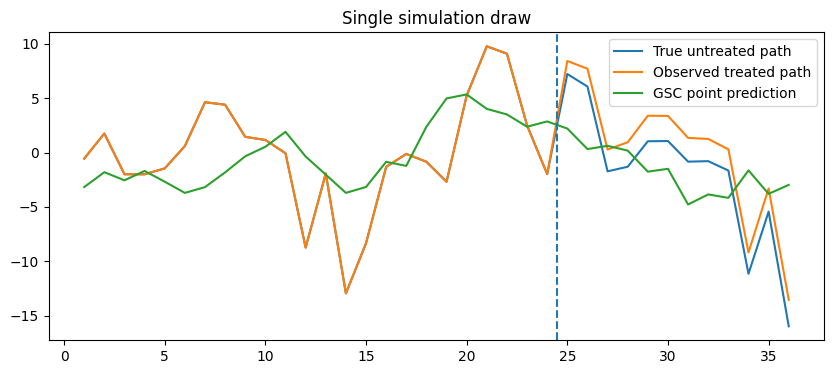

In [ ]:
# Single-run smoke test (candidate evaluation is batched on GPU when CUDA is available)
run0 = evaluate_one_dataset(SEED)
print('true path accepted:', {'block': run0['true_in_block'], 'global': run0['true_in_global']})
print('set size:', {'block': run0['set_size_block'], 'global': run0['set_size_global']})

sim = run0['sim']; fs = run0['fs']
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(np.arange(1, T_TOTAL+1), sim.true_y0_untreated, label='True untreated path')
ax.plot(np.arange(1, T_TOTAL+1), sim.observed_y0, label='Observed treated path')
ax.plot(np.arange(1, T_TOTAL+1), fs['y_hat'][0:T_TOTAL], label='GSC point prediction')
ax.axvline(T0 + 0.5, linestyle='--')
ax.legend(); ax.set_title('Single simulation draw')
plt.show()

In [ ]:
# Monte Carlo study
runs = []
for rep in tqdm(range(N_REP)):
    runs.append(evaluate_one_dataset(SEED + 100*rep))

summary_df = pd.DataFrame([{
    'coverage_block': int(r['true_in_block']),
    'coverage_global': int(r['true_in_global']),
    'set_size_block': r['set_size_block'],
    'set_size_global': r['set_size_global'],
} for r in runs])

summary_stats = pd.DataFrame({
    'method': ['Latent-regime block', 'Chernozhukov-style global'],
    'empirical_path_coverage': [summary_df.coverage_block.mean(), summary_df.coverage_global.mean()],
    'avg_set_size': [summary_df.set_size_block.mean(), summary_df.set_size_global.mean()],
    'median_set_size': [summary_df.set_size_block.median(), summary_df.set_size_global.median()],
})
summary_stats

  0%|          | 0/10 [00:00<?, ?it/s]













 r* = 1















 r* = 2















 r* = 2















 r* = 1















 r* = 2















 r* = 2















 r* = 2















 r* = 2















 r* = 1















 r* = 2





,method,empirical_path_coverage,avg_set_size,median_set_size
0,Latent-regime block,1.0,499.4,500.0
1,Chernozhukov-style global,0.0,1.0,1.0


In [ ]:
import numpy as np
# Check the residuals by regime in the last simulation run
sim = run0['sim']
fs = run0['fs']
resid = sim.observed_y0 - fs['y_hat']
regimes = sim.true_regime

regime_stats = []
for r in range(3):
    mask = (regimes == r)
    if mask.any():
        regime_stats.append({
            'regime': r,
            'count': mask.sum(),
            'std': np.std(resid[mask])
        })

display(pd.DataFrame(regime_stats))
print(f"Global Pre-treatment STD: {np.std(resid[:T0]):.4f}")

,regime,count,std
0,0,12,3.248810
1,1,10,4.666725
2,2,14,4.791916


Global Pre-treatment STD: 4.5057


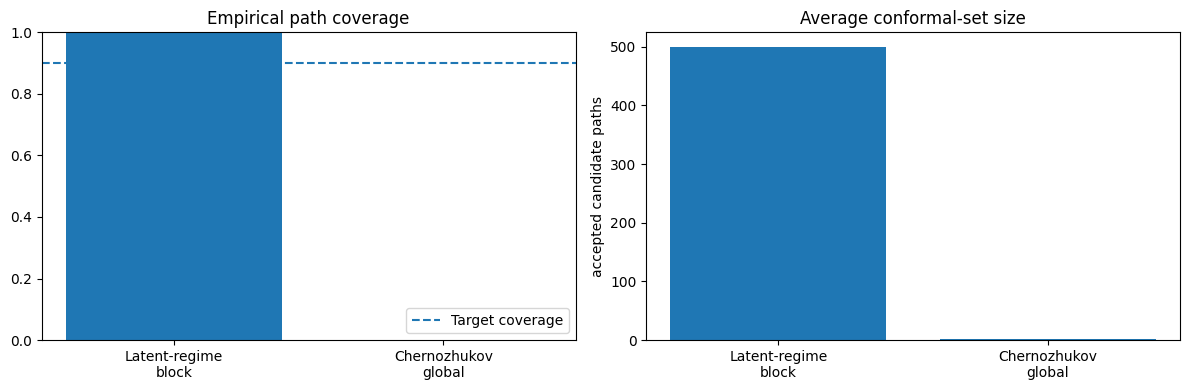

Interpretation: the latent-regime method now uses contiguous block permutations built from the paired (regime, discretized residual) sequence. Higher coverage is better; smaller set size is better conditional on coverage.


In [ ]:
# Accuracy visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Latent-regime\nblock', 'Chernozhukov\nglobal'], [summary_df.coverage_block.mean(), summary_df.coverage_global.mean()])
axes[0].axhline(1 - ALPHA, linestyle='--', label='Target coverage')
axes[0].set_ylim(0, 1)
axes[0].set_title('Empirical path coverage')
axes[0].legend()
axes[1].bar(['Latent-regime\nblock', 'Chernozhukov\nglobal'], [summary_df.set_size_block.mean(), summary_df.set_size_global.mean()])
axes[1].set_title('Average conformal-set size')
axes[1].set_ylabel('accepted candidate paths')
plt.tight_layout(); plt.show()
print('Interpretation: the latent-regime method now uses an (i,j)-block partition: each block starts at a paired (regime, discretized residual) value and runs until that same starting pair appears again. Blocks are equivalent if they share the same starting pair. Higher coverage is better; smaller set size is better conditional on coverage.')

In [ ]:
# Save outputs
summary_df.to_csv('simulation_summary.csv', index=False)
summary_stats.to_csv('simulation_summary_stats.csv', index=False)
with open('run_configuration.json', 'w') as f:
    import json
    json.dump({'ALPHA': ALPHA, 'N_REP': N_REP, 'N_DONORS': N_DONORS, 'T_TOTAL': T_TOTAL, 'T0': T0, 'T1': T1, 'N_CANDIDATES': N_CANDIDATES, 'N_PERM': N_PERM, 'N_BINS': N_BINS, 'N_JOBS': N_JOBS, 'SEED': SEED}, f, indent=2)
print('Wrote summary CSVs and configuration JSON.')